In [4]:
import pandas as pd
import japanize_matplotlib
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import to_rgba
import numpy as np

### 避難率データの推移

### CSVデータ取り込み

In [5]:
# 読み込むデータの条件
FOLDERID = "Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724ff05f7c"
AREA = "Yokosuka"
AGENTS_MODE = False
EPSODERANGE = (0, 10)

# 読み込むデータのパス
modeName = "AgentsModel" if AGENTS_MODE else "EvacueesOnly"
dfs: list[pd.DataFrame] = []
for episode in range(EPSODERANGE[0], EPSODERANGE[1]+1):
    filePath = f"../../Master-Simulator/Assets/Datas/{FOLDERID}/{AREA}_{modeName}_Ep-{episode}_evacuationRate.csv"

    df = pd.read_csv(filePath, header=0)
    # column名から余分なスペースを削除
    df.columns = df.columns.str.replace(" ", "")
    # 読み込みのデータフレームをリストに追加
    dfs.append(df)
    print(f"{filePath} is loaded.")

dfs[0].head(2)

../../Master-Simulator/Assets/Datas/Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724ff05f7c/Yokosuka_EvacueesOnly_Ep-0_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724ff05f7c/Yokosuka_EvacueesOnly_Ep-1_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724ff05f7c/Yokosuka_EvacueesOnly_Ep-2_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724ff05f7c/Yokosuka_EvacueesOnly_Ep-3_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724ff05f7c/Yokosuka_EvacueesOnly_Ep-4_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724ff05f7c/Yokosuka_EvacueesOnly_Ep-5_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_EvacueesOnly_043b8a7f-b658-44b8-92db-7c724f

,EvacuationRate,ElapsedSec
0,0.0,0.02
1,0.0,0.04


### エピソード毎の避難率をプロット

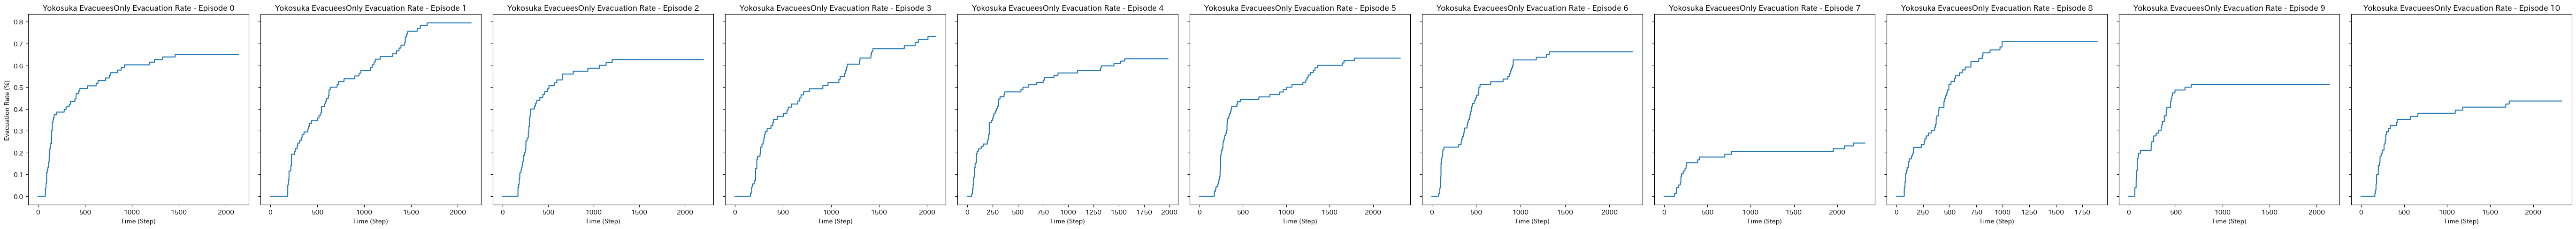

In [6]:
num_episodes = EPSODERANGE[1] - EPSODERANGE[0] + 1
fig, axes = plt.subplots(1, num_episodes, figsize=(5 * num_episodes, 5), sharey=True)

for i, episode in enumerate(range(EPSODERANGE[0], EPSODERANGE[1] + 1)):
    df = dfs[episode]
    ax = axes[i]
    ax.plot(df["ElapsedSec"], df["EvacuationRate"], label=f"Episode {episode}")
    ax.set_title(f"{AREA} {modeName} Evacuation Rate - Episode {episode}")
    ax.set_xlabel("Time (Step)")
    ax.set_ylabel("Evacuation Rate (%)" if i == 0 else "")  # Y軸ラベルは最初のプロットのみ表示
    
plt.tight_layout()
plt.show()

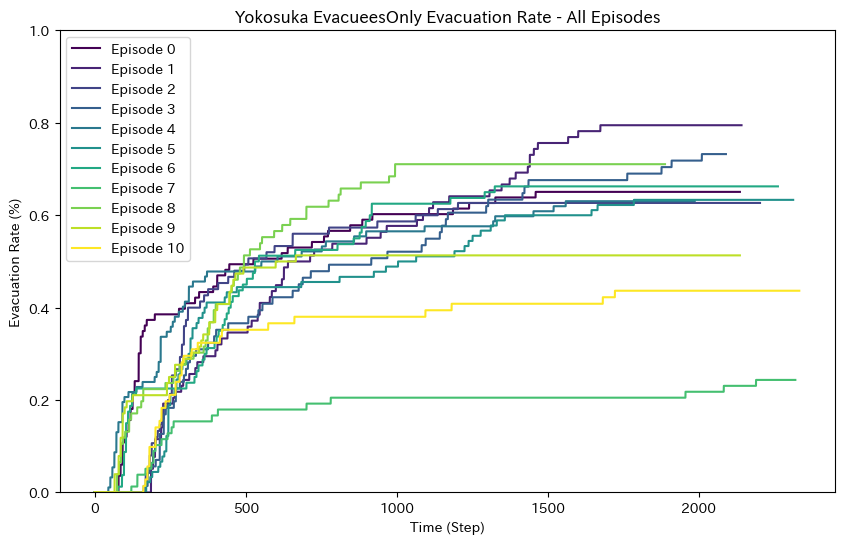

In [8]:
# カラーマップを使ってエピソードごとに色を自動的に割り当て
colors = cm.viridis(np.linspace(0, 1, EPSODERANGE[1] - EPSODERANGE[0] + 1))

plt.figure(figsize=(10, 6))

for i, episode in enumerate(range(EPSODERANGE[0], EPSODERANGE[1] + 1)):
    df = dfs[episode]
    plt.plot(df["ElapsedSec"], df["EvacuationRate"], color=colors[i], label=f"Episode {episode}")

plt.ylim(0, 1.0)
plt.title(f"{AREA} {modeName} Evacuation Rate - All Episodes")
plt.xlabel("Time (Step)")
plt.ylabel("Evacuation Rate (%)")
plt.legend()
plt.show()

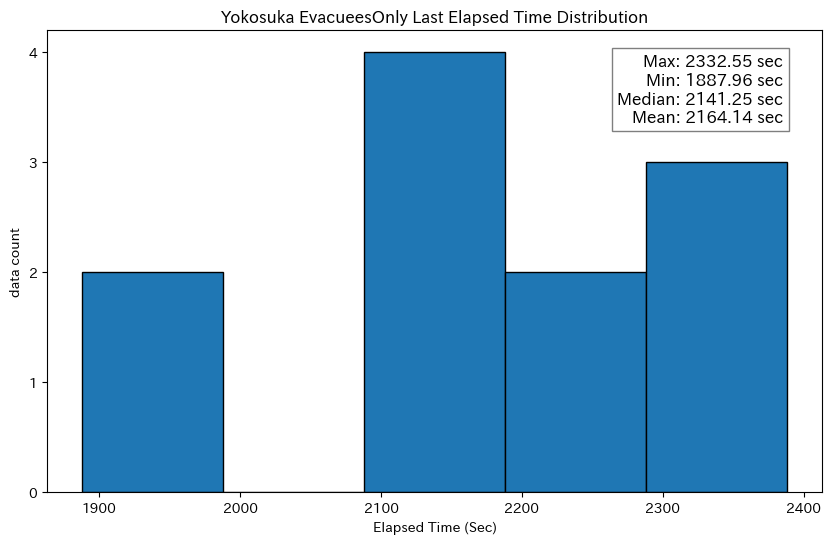

In [12]:
# 制限時間別のデータ数分布をヒストグラムでプロット
# 各エピソードの最後のElapsedSecを抽出
last_elapsed_times = [df["ElapsedSec"].iloc[-1] for df in dfs]

# ヒストグラムをプロット
plt.figure(figsize=(10, 6))
plt.hist(last_elapsed_times, bins=np.arange(min(last_elapsed_times), max(last_elapsed_times) + 100, 100), edgecolor='black')
plt.gca().yaxis.get_major_locator().set_params(integer=True)
plt.title(f"{AREA} {modeName} Last Elapsed Time Distribution")
plt.xlabel("Elapsed Time (Sec)")
plt.ylabel("data count")

# 最大値、最小値、中央値、平均値を計算
max_time = max(last_elapsed_times)
min_time = min(last_elapsed_times)
median_time = np.median(last_elapsed_times)
mean_time = np.mean(last_elapsed_times)

# グラフ内にテキストで表示
textstr = '\n'.join((
    f'Max: {max_time:.2f} sec',
    f'Min: {min_time:.2f} sec',
    f'Median: {median_time:.2f} sec',
    f'Mean: {mean_time:.2f} sec',
))

# テキストの位置を指定して表示
plt.gca().text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top', horizontalalignment='right',
               bbox=dict(facecolor='white', alpha=0.5))
plt.show()
